In [1]:
!python -V

Python 3.9.12


In [2]:
# import ML deps
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope


from sklearn.metrics import root_mean_squared_error, mean_squared_error

/home/codespace/anaconda3/envs/mlops-zc/lib/python3.9/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# set ML experiment tracking
import mlflow

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('demo-experiment-nyc-taxi-pred')

2026/06/19 21:43:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 21:43:37 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/learning-MLOps/mlops-zoomcamp/mlruns/1', creation_time=1781818027744, experiment_id='1', last_update_time=1781818027744, lifecycle_stage='active', name='demo-experiment-nyc-taxi-pred', tags={}>

In [4]:
# ingest & read data
df = pd.read_parquet('./data/green_tripdata_2026-01.parquet')

In [ ]:
# inspect data
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


#### modelling #1

In [ ]:
# data prep
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [ ]:
# feature selection
train_dicts = df[categorical + numerical].to_dict(orient='records')
target = 'duration'

# set train set 
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
y_train = df[target].values

# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_train)

# eval
root_mean_squared_error(y_train, y_pred)

8.048606200417199

/tmp/ipykernel_19170/1196719062.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_19170/1196719062.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


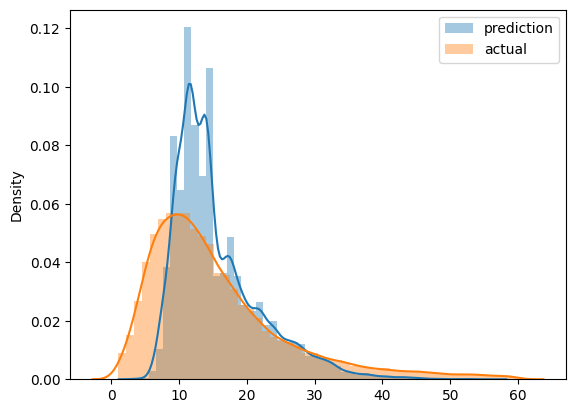

In [16]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend();

#### modelling #2 (cleaner)

In [5]:
# data wrangling func
def read_dataframe(filename) -> pd.DataFrame:
    if filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [6]:
# ingest data 
df_train = read_dataframe('./data/green_tripdata_2026-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2026-02.parquet')

# feature engineering | gotten from EDA
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [7]:
# feature selection
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID'] new feature selction
numerical = ['trip_distance']
target = 'duration'


# train and val set data prep
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

y_train = df_train[target].values
y_val = df_val[target].values

In [14]:
# model
lr = LinearRegression()
lr.fit(X_train, y_train)

# predict
y_pred = lr.predict(X_val)

# eval
root_mean_squared_error(y_val, y_pred)

7.108783270850662

In [ ]:
# dump model
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [ ]:
# try a different model
lr = Lasso(0.01)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.105442824302282

#### Implementing MLflow for experiment tracking

In [ ]:
with mlflow.start_run():
    
    mlflow.set_tag('developer', 'willcodes')

    # log train and val data paths as params
    mlflow.log_param('train-data-path', './data/green_tripdata_2026-01.parquet')
    mlflow.log_param('val-data-path', './data/green_tripdata_2026-02.parquet')

    # log hyperparam
    alpha = .01 
    mlflow.log_param('alpha', alpha)

    # model
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    
    # pred
    y_pred = lr.predict(X_val)

    # eval
    rmse = mean_squared_error(y_val, y_pred, squared=False)

    # log eval metric
    mlflow.log_metric('rmse', rmse)
    

In [9]:
train = xgb.DMatrix(X_train, y_train)
val = xgb.DMatrix(X_val, y_val)


def objective(params):
    with mlflow.start_run():

        # init some mlflow oversight
        mlflow.set_tag('model', 'xgboost')
        mlflow.log_params(params) # track params

        # train
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(val, 'validation')],
            early_stopping_rounds=50
        )
        
        # pred
        y_pred = booster.predict(val)
        
        # eval
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric('rmse', rmse)

    return {'loss': rmse, 'status': STATUS_OK }



search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed':42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=3,
    trials=Trials()
)


[0]	validation-rmse:8.63310                          
  0%|          | 0/3 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/envs/mlops-zc/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:13:14] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[1]	validation-rmse:7.59143                          
[2]	validation-rmse:6.99590                          
[3]	validation-rmse:6.66146                          
[4]	validation-rmse:6.48058                          
[5]	validation-rmse:6.37404                          
[6]	validation-rmse:6.31420                          
[7]	validation-rmse:6.28064                          
[8]	validation-rmse:6.25812                          
[9]	validation-rmse:6.24336                          
[10]	validation-rmse:6.23286                         
[11]	validation-rmse:6.22494                         
[12]	validation-rmse:6.21934                         
[13]	validation-rmse:6.21510                         
[14]	validation-rmse:6.20840                         
[15]	validation-rmse:6.20425                         
[16]	validation-rmse:6.20309                         
[17]	validation-rmse:6.20009                         
[18]	validation-rmse:6.19673                         
[19]	validation-rmse:6.19425

/home/codespace/anaconda3/envs/mlops-zc/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:13:34] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:9.57955                                                   
[1]	validation-rmse:8.91736                                                   
[2]	validation-rmse:8.37899                                                   
[3]	validation-rmse:7.92509                                                   
[4]	validation-rmse:7.56191                                                   
[5]	validation-rmse:7.27374                                                   
[6]	validation-rmse:7.04179                                                   
[7]	validation-rmse:6.85352                                                   
[8]	validation-rmse:6.70839                                                   
[9]	validation-rmse:6.59341                                                   
[10]	validation-rmse:6.49909                                                  
[11]	validation-rmse:6.43536                                                  
[12]	validation-rmse:6.37673                        

/home/codespace/anaconda3/envs/mlops-zc/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [22:14:13] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:9.77818                                                   
[1]	validation-rmse:9.26197                                                   
[2]	validation-rmse:8.81486                                                   
[3]	validation-rmse:8.42882                                                   
[4]	validation-rmse:8.08597                                                   
[5]	validation-rmse:7.80262                                                   
[6]	validation-rmse:7.54978                                                   
[7]	validation-rmse:7.34800                                                   
[8]	validation-rmse:7.16249                                                   
[9]	validation-rmse:7.00996                                                   
[10]	validation-rmse:6.88195                                                  
[11]	validation-rmse:6.77034                                                  
[12]	validation-rmse:6.68324                        